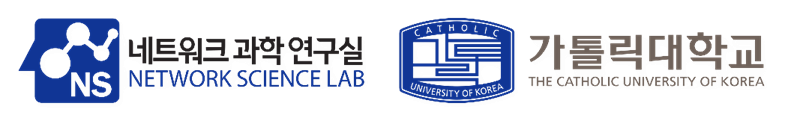

<h1><center><b>💻 Practice 14:</b> </br> Dynamic GRL</center></h1>

# 1. TIMERS: Error-Bounded SVD Restart on Dynamic Networks

## 1.1. Setup

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import eigs, svds

# Project root (notebook directory)
ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data' / 'dblp_mini'

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)

## 1.2. DBLP-mini dataset

Use a **synthetic DBLP-inspired** co-authorship graph:

| File | Description |
|------|-------------|
| `authors.csv` | Author id and name |
| `edges_static.csv` | Early collaborations (initial graph `A`) |
| `edges_dynamic.csv` | New collaborations arriving over time (`E`) |

Re-generate data anytime:

```bash
python data/dblp_mini/build_dblp_mini.py
```

In [2]:
def load_dblp_mini(data_dir: Path = DATA_DIR):
    with open(data_dir / 'authors.csv', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        authors = [row['name'] for row in reader]

    def read_edges(fname):
        edges = []
        with open(data_dir / fname, encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                edges.append((int(row['u']), int(row['v']), int(row['year'])))
        return edges

    static = read_edges('edges_static.csv')
    dynamic = read_edges('edges_dynamic.csv')
    n = len(authors)

    rows, cols = zip(*[(u, v) for u, v, _ in static])
    A = sparse.coo_matrix((np.ones(len(static)), (rows, cols)), shape=(n, n)).tocsr()
    A = A + A.T

    E = np.array([(u, v) for u, v, _ in dynamic], dtype=int)
    return authors, A, E, static, dynamic

authors, A, E, static_edges, dynamic_edges = load_dblp_mini()
print(f'Authors: {len(authors)}')
print(f'Static edges: {len(static_edges)} | Dynamic edges: {len(dynamic_edges)}')
print(f'Example authors: {authors[:5]}')

Authors: 59
Static edges: 52 | Dynamic edges: 99
Example authors: ['Michael Stonebraker', 'Hector Garcia-Molina', 'Raghu Ramakrishnan', 'Surajit Chaudhuri', 'AnHai Doan']


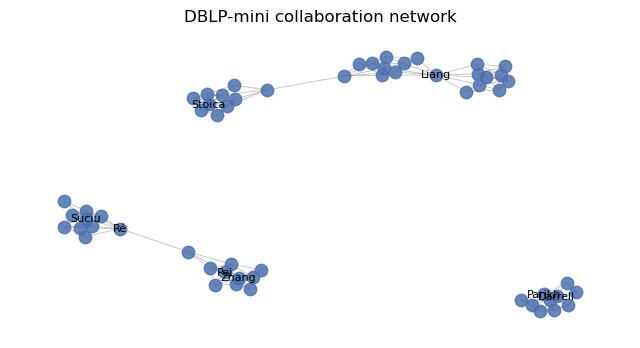

In [3]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from(range(len(authors)))
G.add_edges_from([(u, v) for u, v, _ in static_edges])
G.add_edges_from([(u, v) for u, v, _ in dynamic_edges])

deg = dict(G.degree())
top = sorted(deg, key=deg.get, reverse=True)[:8]
labels = {i: authors[i].split()[-1] for i in top}

pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=80, node_color='#4C72B0', alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
plt.title('DBLP-mini collaboration network')
plt.axis('off')
plt.show()

## 1.3. Core objective and bound

TIMERS tracks the factorization loss

$$ \mathcal{L} = \| S - UV^\top \|_F^2 $$

and restarts SVD when the current loss exceeds `(1 + θ)` times a **provable lower bound** (`RefineBound`).

In [4]:
def obj(sim, u, v):
    """||S - U V^T||_F^2 — memory-efficient (see Obj.m)."""
    _, k = u.shape
    ps_u, ps_v = u.T @ u, v.T @ v
    coo = sim.tocoo()
    loss = float(np.sum(coo.data ** 2))
    row, col, val = coo.row, coo.col, coo.data
    m = len(val)
    for i in range(k):
        s, e = (i * m) // k, ((i + 1) * m) // k
        inner = np.sum(u[row[s:e], :] * v[col[s:e], :], axis=1)
        loss -= 2.0 * np.sum(val[s:e] * inner)
    return loss + float(np.sum(ps_u * ps_v))


def obj_sim_change(s_ori, s_add, u, v, loss_ori):
    """Incremental loss after S <- S + ΔS (Obj_SimChange.m)."""
    _, k = u.shape
    coo = s_add.tocoo()
    row, col, val = coo.row, coo.col, coo.data
    old = np.array(s_ori[row, col]).ravel()
    m = len(val)
    loss_new = loss_ori
    for i in range(k):
        s, e = (i * m) // k, ((i + 1) * m) // k
        inner = np.sum(u[row[s:e], :] * v[col[s:e], :], axis=1)
        loss_new -= np.sum((old[s:e] - inner) ** 2)
        loss_new += np.sum((old[s:e] + val[s:e] - inner) ** 2)
    return float(loss_new)


def refine_bound(s_ori, s_add, loss_ori, k):
    """Lower bound after perturbation (RefineBound.m)."""
    overlap = s_add.multiply(s_ori)
    s_temp = s_add + overlap
    trace_change = float(s_temp.power(2).sum() - overlap.power(2).sum())

    delta = (s_ori @ s_add + s_add @ s_ori.T + s_add @ s_add).tocsr()
    active = np.unique(delta.nonzero()[0])
    if active.size == 0:
        eigen_sum = 0.0
    else:
        sub = delta[active][:, active]
        nev = min(max(2 * k, 1), sub.shape[0] - 1) if sub.shape[0] > 1 else 1
        w, _ = eigs(sub.astype(float), k=nev, which='LM')
        ev = np.sort(np.real(w)[np.real(w) >= 0])[::-1]
        if len(ev) >= k:
            eigen_sum = float(ev[:k].sum())
        elif len(ev) == 0:
            eigen_sum = 0.0
        else:
            eigen_sum = float(ev.sum() + ev[-1] * (k - len(ev)))
    return loss_ori + trace_change - eigen_sum

## 1.4. TIMERS dynamic loop

In [5]:
def edges_to_sparse(edge_array, n):
    if len(edge_array) == 0:
        return sparse.csr_matrix((n, n))
    mat = sparse.coo_matrix((np.ones(len(edge_array)), (edge_array[:, 0], edge_array[:, 1])), shape=(n, n))
    return (mat + mat.T).tocsr()


def svd_embed(sim, k):
    u, s, vt = svds(sim.astype(float), k=k)
    order = np.argsort(-s)
    u, s, vt = u[:, order], s[order], vt[order, :]
    sqrt_s = np.sqrt(s)
    u_emb, v_emb = u * sqrt_s, vt.T * sqrt_s
    return u_emb, v_emb, obj(sim, u_emb, v_emb)


def run_timers(A, E, k=8, theta=0.3, time_slice=10, verbose=True):
    """TIMERS main loop (TIMERS_Sample.m)."""
    n = A.shape[0]
    sim_static = A.copy()
    s_cum = A.copy()
    s_perturb = sparse.csr_matrix((n, n))

    loss_store = np.zeros(time_slice + 1)
    loss_bound = np.zeros(time_slice + 1)
    rerun_at = []

    u_cur, v_cur, loss = svd_embed(s_cum, k)
    loss_store[0] = loss_bound[0] = loss
    loss_rerun = loss

    new_edge_num = len(E)
    for i in range(1, time_slice + 1):
        start = int(np.floor((i - 2) * new_edge_num / time_slice))
        end = int(np.floor((i - 1) * new_edge_num / time_slice))
        s_add = edges_to_sparse(E[start:end], n)
        s_perturb = s_perturb + s_add

        loss_store[i] = obj_sim_change(s_cum, s_add, u_cur, v_cur, loss_store[i - 1])
        loss_bound[i] = refine_bound(sim_static, s_perturb, loss_rerun, k)
        s_cum = s_cum + s_add

        if loss_store[i] >= (1 + theta) * loss_bound[i]:
            if verbose:
                print(f'Restart SVD at slice {i}')
            rerun_at.append(i)
            sim_static = s_cum.copy()
            s_perturb = sparse.csr_matrix((n, n))
            u_cur, v_cur, loss_rerun = svd_embed(sim_static, k)
            loss_store[i] = loss_bound[i] = loss_rerun

    # Optimal baseline: full SVD every slice
    loss_opt = np.zeros(time_slice + 1)
    s_opt = A.copy()
    _, _, loss_opt[0] = svd_embed(s_opt, k)
    for i in range(1, time_slice + 1):
        start = int(np.floor((i - 2) * new_edge_num / time_slice))
        end = int(np.floor((i - 1) * new_edge_num / time_slice))
        s_opt = s_opt + edges_to_sparse(E[start:end], n)
        _, _, loss_opt[i] = svd_embed(s_opt, k)

    return {
        'loss_store': loss_store,
        'loss_bound': loss_bound,
        'loss_optimal': loss_opt,
        'rerun_at': rerun_at,
        'U': u_cur,
        'V': v_cur,
    }

## 1.5. Train and evaluate

- `K` — embedding dimension
- `θ` — error tolerance for restart (larger θ ⇒ fewer restarts, looser tracking)
- `time_slice` — number of dynamic snapshots

In [6]:
K = 8
THETA = 0.3
TIME_SLICE = 10

result = run_timers(A, E, k=K, theta=THETA, time_slice=TIME_SLICE)

ratio = result['loss_store'] / np.maximum(result['loss_optimal'], 1e-12)
print('SVD restarts at slices:', result['rerun_at'])
print('Max relative gap vs optimal:', float(ratio.max() - 1))
print('Final loss — TIMERS:', round(result['loss_store'][-1], 2),
      '| Optimal:', round(result['loss_optimal'][-1], 2))

Restart SVD at slice 2
Restart SVD at slice 3
Restart SVD at slice 4
Restart SVD at slice 5
Restart SVD at slice 6
Restart SVD at slice 7
Restart SVD at slice 8
Restart SVD at slice 10
SVD restarts at slices: [2, 3, 4, 5, 6, 7, 8, 10]
Max relative gap vs optimal: 0.06671312495835413
Final loss — TIMERS: 110.42 | Optimal: 110.42


## 1.6. Visualize

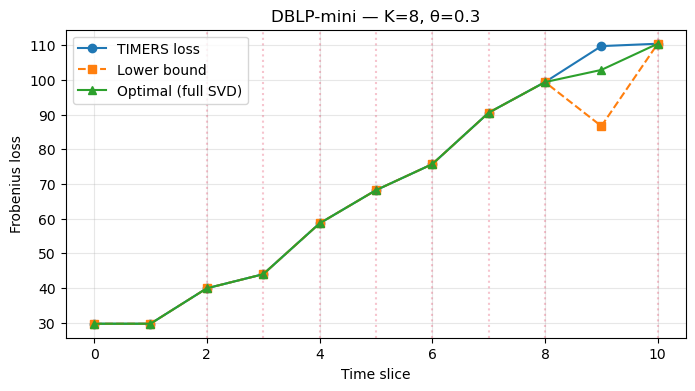

In [7]:
t = np.arange(TIME_SLICE + 1)
plt.plot(t, result['loss_store'], 'o-', label='TIMERS loss')
plt.plot(t, result['loss_bound'], 's--', label='Lower bound')
plt.plot(t, result['loss_optimal'], '^-', label='Optimal (full SVD)')
for r in result['rerun_at']:
    plt.axvline(r, color='crimson', alpha=0.25, linestyle=':')
plt.xlabel('Time slice')
plt.ylabel('Frobenius loss')
plt.title(f'DBLP-mini — K={K}, θ={THETA}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

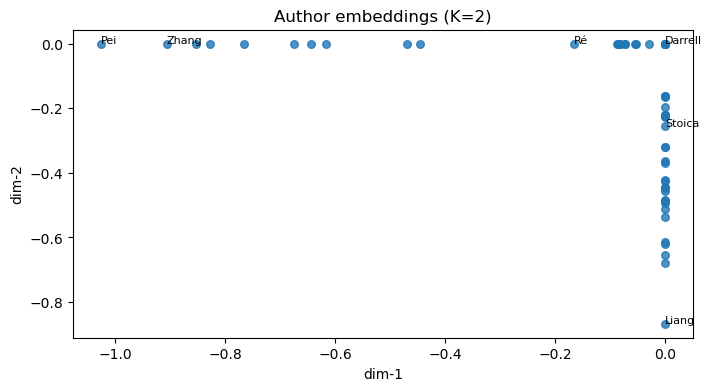

In [8]:
# 2-D embedding visualization (top-2 singular vectors)
deg = dict(G.degree())
u2, v2, _ = svd_embed(A + edges_to_sparse(E, len(authors)), k=2)
plt.scatter(u2[:, 0], u2[:, 1], s=30, alpha=0.8)
for i in sorted(deg, key=deg.get, reverse=True)[:6]:
    plt.annotate(authors[i].split()[-1], (u2[i, 0], u2[i, 1]), fontsize=8)
plt.title('Author embeddings (K=2)')
plt.xlabel('dim-1'); plt.ylabel('dim-2')
plt.show()

# 2. dynnode2vec: Scalable Dynamic Network Embedding

**Idea:** Extend **node2vec** to **dynamic graphs** by:

1. Running full node2vec on the first snapshot $G_1$.
2. For each later snapshot $G_t$, sample random walks only for **evolving nodes** $\Delta V_t$ (Eq. 1).
3. **Warm-start** skip-gram with embeddings from $t-1$ (dynamic skip-gram).



## 2.1. Word2Vec

In [9]:
from collections import defaultdict

class _WordVectors:
    def __init__(self, model):
        self._model = model

    @property
    def index_to_key(self):
        return list(self._model.index2word)

    @property
    def key_to_index(self):
        return dict(self._model.word2index)

    def __contains__(self, key):
        return key in self._model.word2index

    def __getitem__(self, key):
        return self._model.syn0[self._model.word2index[key]]

    def __setitem__(self, key, value):
        vector = np.asarray(value, dtype=float)
        if vector.shape != (self._model.vector_size,):
            raise ValueError(f'Expected vector of shape {(self._model.vector_size,)}, got {vector.shape}')
        if key not in self._model.word2index:
            self._model._add_word(key)
        self._model.syn0[self._model.word2index[key]] = vector


class Word2Vec:
    def __init__(
        self,
        sentences=None,
        size=100,
        vector_size=100,
        seed=0,
        workers=4,
        window=5,
        negative=5,
        alpha=0.025,
        min_count=1,
        sg=1,
        iter=5,
        num_threads=4,
        epochs=5,
    ):
        self.sentences = list(sentences) if sentences is not None else []
        self.size = vector_size if vector_size is not None else size
        self.vector_size = self.size
        self.window = window
        self.negative = negative
        self.alpha = alpha
        self.iter = iter
        self.epochs = epochs
        self.min_count = min_count
        self.sg = sg
        self.num_threads = num_threads
        self.seed = seed
        self.workers = workers
        self.rng = np.random.default_rng(seed)
        self.vocab = defaultdict(int)
        self.index2word = []
        self.word2index = {}
        self.syn0 = None
        self.syn1neg = None
        self.corpus_count = 0
        self.wv = _WordVectors(self)

        if self.sentences:
            self.build_vocab(self.sentences)
            self.train(self.sentences, epochs=self.epochs)

    def _random_vector(self):
        return self.rng.uniform(-0.5 / self.vector_size, 0.5 / self.vector_size, self.vector_size)

    def _add_word(self, word):
        if word in self.word2index:
            return
        self.word2index[word] = len(self.index2word)
        self.index2word.append(word)
        if self.syn0 is not None:
            self.syn0 = np.vstack([self.syn0, self._random_vector()])
            self.syn1neg = np.vstack([self.syn1neg, np.zeros(self.vector_size, dtype=float)])

    def build_vocab(self, sentences=None, update=False):
        if sentences is not None:
            self.sentences = list(sentences)

        if not update:
            self.vocab = defaultdict(int)

        for sentence in self.sentences:
            for word in sentence:
                self.vocab[word] += 1

        previous_vectors = None
        if update and self.syn0 is not None and self.index2word:
            previous_vectors = {word: self.syn0[idx].copy() for word, idx in self.word2index.items()}

        self.index2word = [word for word, count in self.vocab.items() if count >= self.min_count]
        self.word2index = {word: idx for idx, word in enumerate(self.index2word)}
        self.corpus_count = len(self.sentences)
        self.init_weights()

        if previous_vectors:
            for word, vec in previous_vectors.items():
                if word in self.word2index:
                    self.syn0[self.word2index[word]] = vec

        return self

    def init_weights(self):
        vocab_size = len(self.index2word)
        self.syn0 = self.rng.uniform(-0.5 / self.vector_size, 0.5 / self.vector_size, (vocab_size, self.vector_size))
        self.syn1neg = np.zeros((vocab_size, self.vector_size), dtype=float)

    def train(self, sentences=None, total_examples=None, epochs=None):
        if sentences is not None:
            self.sentences = list(sentences)

        if self.syn0 is None or len(self.index2word) != len(self.word2index):
            self.build_vocab(self.sentences, update=False)

        self.train_process(self.sentences, epochs=epochs if epochs is not None else self.epochs)
        return self

    def train_process(self, sentences=None, epochs=None):
        sentences = self.sentences if sentences is None else sentences
        epochs = self.epochs if epochs is None else epochs
        for _ in range(epochs):
            for sentence in sentences:
                self.train_epoch(sentence)

    def train_epoch(self, sentence):
        for i, word in enumerate(sentence):
            if word not in self.word2index:
                continue
            word_idx = self.word2index[word]
            start = max(0, i - self.window)
            end = min(len(sentence), i + self.window + 1)
            for j in range(start, end):
                if j == i:
                    continue
                context_word = sentence[j]
                if context_word in self.word2index:
                    context_idx = self.word2index[context_word]
                    self.train_pair(word_idx, context_idx)

    def train_pair(self, word_idx, context_idx):
        l1 = self.syn0[word_idx]
        l2 = self.syn1neg[context_idx]
        product = np.dot(l1, l2)
        g = self.alpha * (1 - product)
        self.syn0[word_idx] += g * l2
        self.syn1neg[context_idx] += g * l1

    def get_embeddings(self):
        return {word: self.syn0[idx] for word, idx in self.word2index.items()}

## 2.2. Setup

In [10]:
import csv
from collections import defaultdict
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.manifold import TSNE

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data' / 'dblp_mini'
WORK_DIR = ROOT / 'temp_dynnode2vec_nb'

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)

## 2.3. DBLP temporal snapshots

Cumulative co-authorship graphs: each snapshot adds collaborations up to a given year.

| File | Role |
|------|------|
| `authors.csv` | Node id → author name |
| `edges_static.csv` | Early edges |
| `edges_dynamic.csv` | Edges with year (temporal order) |

Regenerate: `python data/dblp_mini/build_dblp_mini.py`

In [11]:
def load_dblp_snapshots(data_dir: Path = DATA_DIR, n_snapshots: int = 8):
    with open(data_dir / 'authors.csv', encoding='utf-8') as f:
        authors = [row['name'] for row in csv.DictReader(f)]

    edges = []
    for fname in ('edges_static.csv', 'edges_dynamic.csv'):
        with open(data_dir / fname, encoding='utf-8') as f:
            for row in csv.DictReader(f):
                edges.append((int(row['u']), int(row['v']), int(row['year'])))

    edges.sort(key=lambda x: x[2])
    years = sorted({y for _, _, y in edges})
    if len(years) <= n_snapshots:
        cut_years = years
    else:
        idx = np.linspace(0, len(years) - 1, n_snapshots, dtype=int)
        cut_years = [years[i] for i in idx]

    n = len(authors)
    graphs = []
    for y_cut in cut_years:
        g = nx.Graph()
        g.add_nodes_from(range(n))
        for u, v, y in edges:
            if y <= y_cut:
                g.add_edge(u, v)
        graphs.append(g)
    return authors, graphs, cut_years

authors, graphs, snapshot_years = load_dblp_snapshots()
print(f'Authors: {len(authors)} | Snapshots: {len(graphs)}')
for t, (g, y) in enumerate(zip(graphs, snapshot_years)):
    print(f'  G_{t} (≤{y}): {g.number_of_edges()} edges')

Authors: 59 | Snapshots: 8
  G_0 (≤1998): 2 edges
  G_1 (≤2000): 6 edges
  G_2 (≤2003): 20 edges
  G_3 (≤2005): 41 edges
  G_4 (≤2008): 72 edges
  G_5 (≤2010): 94 edges
  G_6 (≤2013): 132 edges
  G_7 (≤2016): 151 edges


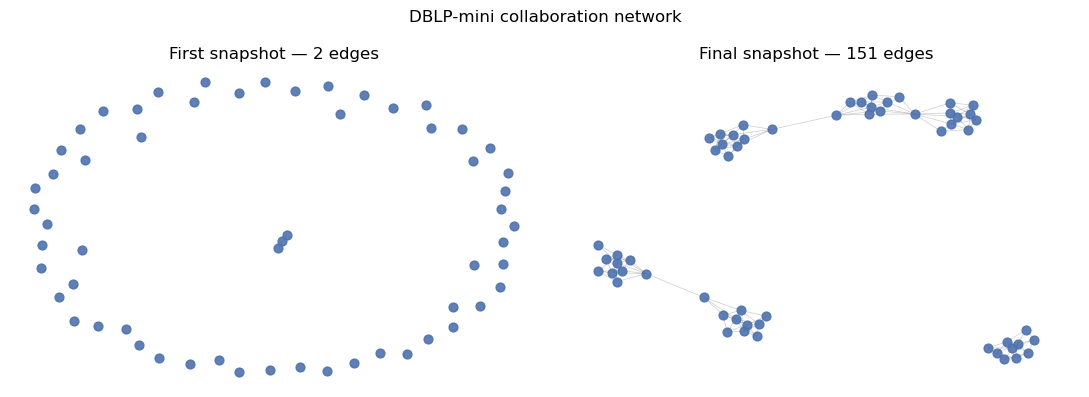

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, idx, title in zip(axes, [0, len(graphs) - 1], ['First snapshot', 'Final snapshot']):
    g = graphs[idx]
    pos = nx.spring_layout(g, seed=42)
    nx.draw_networkx_nodes(g, pos, node_size=40, node_color='#4C72B0', alpha=0.9, ax=ax)
    nx.draw_networkx_edges(g, pos, alpha=0.2, width=0.5, ax=ax)
    ax.set_title(f'{title} — {g.number_of_edges()} edges')
    ax.axis('off')
plt.suptitle('DBLP-mini collaboration network')
plt.tight_layout()
plt.show()

## 2.4. Evolving nodes

$$
\Delta V_t = V_{\mathrm{add}} \cup \{ v_i \in V_t \mid \exists (v_i, v_j) \in E_{\mathrm{add}} \cup E_{\mathrm{del}} \}
$$

Nodes incident to edges that were **added or removed** since the previous snapshot.

In [13]:
def get_delta_nodes(g_prev: nx.Graph, g_cur: nx.Graph) -> set[int]:
    delta_edges = set(map(tuple, g_cur.edges)) ^ set(map(tuple, g_prev.edges))
    return {v for edge in delta_edges for v in edge}

# Example: change from G_0 → G_1
if len(graphs) >= 2:
    d = get_delta_nodes(graphs[0], graphs[1])
    print(f'|ΔV_1| = {len(d)}', 'sample:', sorted(d)[:8])

|ΔV_1| = 7 sample: [1, 3, 4, 5, 7, 8, 9]


## 2.5. node2vec random walks

Second-order biased walks controlled by **p** (return) and **q** (in-out).  
At $t=0$: walks start from **all** nodes. At $t>0$: walks start only from $\Delta V_t$

In [14]:
class Node2VecWalks:
    def __init__(self, graph: nx.Graph, p: float = 1.0, q: float = 1.0, seed: int = 42):
        self.graph = graph
        self.p, self.q = p, q
        self.rng = np.random.default_rng(seed)
        self.neighbors = {n: sorted(graph.neighbors(n)) for n in graph.nodes()}

    def _norm_probs(self, weights):
        s = sum(weights)
        return None if s <= 0 else np.array(weights, float) / s

    def _step(self, prev, cur):
        nbrs = self.neighbors[cur]
        if not nbrs:
            return None
        if prev is None:
            probs = self._norm_probs([1.0] * len(nbrs))
        else:
            w = []
            for nxt in nbrs:
                if nxt == prev:
                    w.append(1.0 / self.p)
                elif self.graph.has_edge(prev, nxt):
                    w.append(1.0)
                else:
                    w.append(1.0 / self.q)
            probs = self._norm_probs(w)
        return None if probs is None else int(self.rng.choice(nbrs, p=probs))

    def generate(self, nodes: Iterable[int], walk_length: int, num_walks: int):
        walks = []
        for source in nodes:
            for _ in range(num_walks):
                walk = [str(source)]
                if not self.neighbors[source]:
                    walks.append(walk)
                    continue
                nxt = self._step(None, source)
                if nxt is None:
                    walks.append(walk)
                    continue
                walk.append(str(nxt))
                while len(walk) < walk_length:
                    nxt = self._step(int(walk[-2]), int(walk[-1]))
                    if nxt is None:
                        break
                    walk.append(str(nxt))
                walks.append(walk)
        return walks

## 2.6. dynnode2vec

In [15]:
def _load_initial_vectors(path, dim):
    out = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= dim + 1:
                out[parts[0]] = np.array(parts[1:dim + 1], float)
    return out


def _apply_initial_vectors(model, path):
    for word, vec in _load_initial_vectors(path, model.vector_size).items():
        if word in model.wv:
            model.wv[word] = vec


def dynnode2vec(
    graphs,
    dimensions=16,
    walk_length=40,
    num_walks=10,
    p=1.0,
    q=1.0,
    window=5,
    epochs=5,
    seed=42,
    work_dir=WORK_DIR,
    verbose=True,
):
    work_dir = Path(work_dir)
    work_dir.mkdir(parents=True, exist_ok=True)

    w0 = Node2VecWalks(graphs[0], p=p, q=q, seed=seed)
    walks0 = w0.generate(graphs[0].nodes(), walk_length, num_walks)
    model = Word2Vec(
        sentences=walks0,
        vector_size=dimensions,
        window=window,
        min_count=0,
        sg=1,
        workers=1,
        seed=seed,
        epochs=epochs,
    )
    with open(work_dir / 'wv_0.emb', 'w', encoding='utf-8') as f:
        for word in model.wv.index_to_key:
            f.write(f"{word} {' '.join(map(str, model.wv[word]))}\n")
    if verbose:
        print(f't=0 | edges={graphs[0].number_of_edges()} walks={len(walks0)}')

    for t in range(1, len(graphs)):
        delta = get_delta_nodes(graphs[t - 1], graphs[t])
        wt = Node2VecWalks(graphs[t], p=p, q=q, seed=seed + t)
        walks = wt.generate(delta, walk_length, num_walks) if delta else []
        prev_emb = work_dir / f'wv_{t - 1}.emb'

        if walks:
            model.build_vocab(walks, update=True)
            if prev_emb.exists():
                _apply_initial_vectors(model, prev_emb)
            model.train(walks, total_examples=model.corpus_count, epochs=model.epochs)
        elif prev_emb.exists():
            _apply_initial_vectors(model, prev_emb)

        with open(work_dir / f'wv_{t}.emb', 'w', encoding='utf-8') as f:
            for word in model.wv.index_to_key:
                f.write(f"{word} {' '.join(map(str, model.wv[word]))}\n")

        if verbose:
            print(f't={t} | |ΔV|={len(delta)} walks={len(walks)} edges={graphs[t].number_of_edges()}')

    return model

## 2.7. Train

In [16]:
DIM = 16
WALK_LENGTH = 40
NUM_WALKS = 8
P, Q = 1.0, 1.0

model = dynnode2vec(
    graphs,
    dimensions=DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P,
    q=Q,
    work_dir=WORK_DIR,
)

t=0 | edges=2 walks=472
t=1 | |ΔV|=7 walks=56 edges=6
t=2 | |ΔV|=18 walks=144 edges=20
t=3 | |ΔV|=24 walks=192 edges=41
t=4 | |ΔV|=29 walks=232 edges=72
t=5 | |ΔV|=29 walks=232 edges=94
t=6 | |ΔV|=33 walks=264 edges=132
t=7 | |ΔV|=24 walks=192 edges=151


## 2.8. Evaluate by link prediction

In [17]:
from sklearn.metrics import roc_auc_score

def link_prediction_auc(graphs, model):
    scores = []
    for t in range(len(graphs) - 1):
        g_cur, g_next = graphs[t], graphs[t + 1]
        new_edges = set(map(tuple, g_next.edges)) - set(map(tuple, g_cur.edges))
        if not new_edges:
            continue
        nodes = list(g_cur.nodes())
        existing = set(map(tuple, g_cur.edges))
        rng = np.random.default_rng(t)
        neg = []
        while len(neg) < min(len(new_edges), 200):
            u, v = rng.integers(0, len(nodes), 2)
            if u == v:
                continue
            a, b = min(u, v), max(u, v)
            if (a, b) not in existing:
                neg.append((a, b))

        def score(a, b):
            sa, sb = str(a), str(b)
            if sa not in model.wv or sb not in model.wv:
                return 0.0
            return float(np.dot(model.wv[sa], model.wv[sb]))

        y = [1] * len(new_edges) + [0] * len(neg)
        s = [score(*e) for e in new_edges] + [score(*e) for e in neg]
        if len(set(y)) == 2:
            scores.append(roc_auc_score(y, s))
    return scores

auc = link_prediction_auc(graphs, model)
print('Link-prediction AUC per step:', [round(x, 3) for x in auc])
if auc:
    print('Mean AUC:', round(float(np.mean(auc)), 3))

Link-prediction AUC per step: [1.0, 0.872, 0.998, 0.89, 0.994, 0.975, 0.773]
Mean AUC: 0.929


## 2.9. Visualize

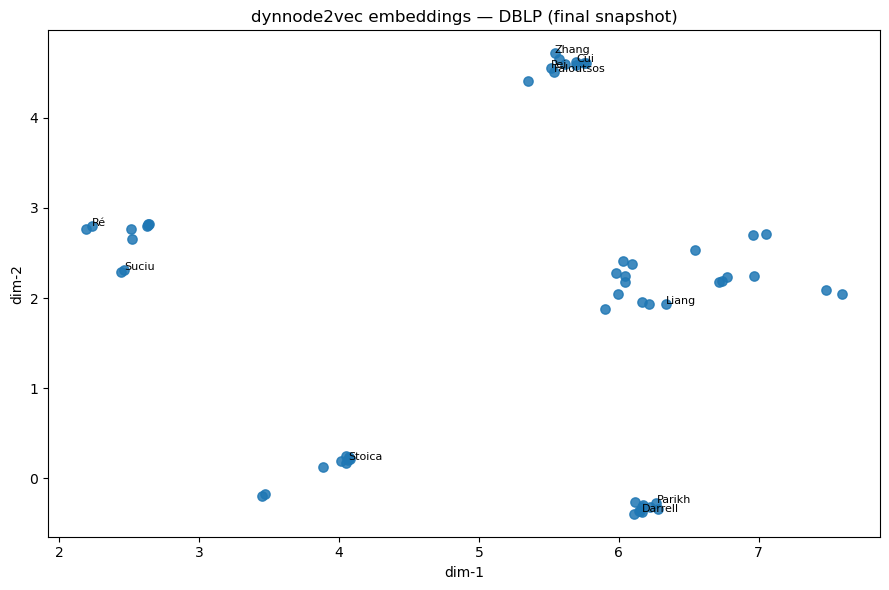

In [18]:
nodes = [str(i) for i in range(len(authors)) if str(i) in model.wv]
vectors = np.array([model.wv[n] for n in nodes])
xy = TSNE(n_components=2, random_state=0, perplexity=min(30, len(vectors) - 1)).fit_transform(vectors)

plt.figure(figsize=(9, 6))
plt.scatter(xy[:, 0], xy[:, 1], s=45, alpha=0.85)
deg = dict(graphs[-1].degree())
for idx in sorted(deg, key=deg.get, reverse=True)[:10]:
    sid = str(idx)
    if sid in model.wv:
        j = nodes.index(sid)
        plt.annotate(authors[idx].split()[-1], xy[j], fontsize=8)
plt.title('dynnode2vec embeddings — DBLP (final snapshot)')
plt.xlabel('dim-1'); plt.ylabel('dim-2')
plt.tight_layout()
plt.show()

# 3. Continuous-Time Dynamic Network Embeddings (CTDNE)

**Core idea:** Learn node embeddings from **temporal random walks** that only follow edges with **non-decreasing timestamps** (valid information flow in time).

## 3.1. Word2Vec

In [19]:
class _WordVectors:
    def __init__(self, model):
        self._model = model

    def __len__(self):
        return len(self._model.index2word)

    def __contains__(self, key):
        return key in self._model.word2index

    def __getitem__(self, key):
        return self._model.syn0[self._model.word2index[key]]

    @property
    def index_to_key(self):
        return list(self._model.index2word)


class Word2Vec:
    def __init__(self, sentences=None, vector_size=100, size=None, window=5, negative=5, alpha=0.025, min_count=1, sg=1, iter=5, num_threads=4, seed=42, workers=1, epochs=5):
        self.sentences = list(sentences) if sentences is not None else []
        self.size = vector_size if size is None else size
        self.vector_size = self.size
        self.window = window
        self.negative = negative
        self.alpha = alpha
        self.min_count = min_count
        self.sg = sg
        self.iter = epochs if iter is None else iter
        self.epochs = epochs
        self.num_threads = num_threads
        self.seed = seed
        self.workers = workers
        self.vocab = defaultdict(int)
        self.index2word = []
        self.word2index = {}
        self.syn0 = None
        self.syn1neg = None
        self.table = None
        self.table_size = int(1e8)
        self.rng = np.random.default_rng(seed)
        self.wv = _WordVectors(self)

        if self.sentences:
            self.build_vocab(self.sentences)
            self.init_weights()
            self.train(self.sentences)

    def build_vocab(self, sentences, update=False):
        if not update:
            self.vocab = defaultdict(int)
        for sentence in sentences:
            for word in sentence:
                self.vocab[word] += 1

        self.index2word = [word for word, count in self.vocab.items() if count >= self.min_count]
        self.word2index = {word: idx for idx, word in enumerate(self.index2word)}

        print(f"Vocabulary size: {len(self.vocab)}")
        print(f"Filtered vocabulary size: {len(self.index2word)}")

    def init_weights(self):
        vocab_size = len(self.index2word)
        self.syn0 = self.rng.uniform(-0.5 / self.size, 0.5 / self.size, (vocab_size, self.size))
        self.syn1neg = np.zeros((vocab_size, self.size))

    def train(self, sentences, total_examples=None, epochs=None):
        if self.syn0 is None:
            self.build_vocab(sentences)
            self.init_weights()
        n_epochs = self.iter if epochs is None else epochs
        for _ in range(n_epochs):
            self.train_epoch(sentences)
        return self

    def train_epoch(self, sentences):
        for sentence in sentences:
            for i, word in enumerate(sentence):
                if word not in self.word2index:
                    continue
                word_idx = self.word2index[word]
                start = max(0, i - self.window)
                end = min(len(sentence), i + self.window + 1)
                for j in range(start, end):
                    if j == i:
                        continue
                    context_word = sentence[j]
                    if context_word in self.word2index:
                        context_idx = self.word2index[context_word]
                        self.train_pair(word_idx, context_idx)

    def train_pair(self, word_idx, context_idx):
        l1 = self.syn0[word_idx]
        l2 = self.syn1neg[context_idx]

        product = np.dot(l1, l2)
        g = self.alpha * (1 - product)

        self.syn0[word_idx] += g * l2
        self.syn1neg[context_idx] += g * l1

    def get_embeddings(self):
        return {word: self.syn0[idx] for word, idx in self.word2index.items()}

## 3.2. Setup

In [20]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data' / 'ia_contacts_hypertext09'
# Use small subset for faster runs; switch to ht2009_contact_list.dat for full data
DATA_FILE = DATA_DIR / 'ht2009_contact_list_small.dat'

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)

## 3.3. Load ia-contacts-hypertext09 dataset

In [21]:
def load_hypertext_contacts(path, undirected=True, max_events=None):
    edges = []
    nodes = set()
    n_read = 0
    with open(path, encoding='utf-8') as f:
        for line in f:
            p = line.split()
            if len(p) < 3:
                continue
            t, u, v = int(p[0]), int(p[1]), int(p[2])
            edges.append((u, v, t))
            nodes.add(u); nodes.add(v)
            if undirected:
                edges.append((v, u, t))
            n_read += 1
            if max_events and n_read >= max_events:
                break
    remap = {old: i for i, old in enumerate(sorted(nodes))}
    mapped = [(remap[u], remap[v], t) for u, v, t in edges]
    return mapped, len(nodes)

edges, num_nodes = load_hypertext_contacts(DATA_FILE)
print(f'Events file: {DATA_FILE.name}')
print(f'Nodes: {num_nodes} | Directed temporal edges: {len(edges)}')
print(f'Time range: {min(t for _,_,t in edges)} - {max(t for _,_,t in edges)}')

Events file: ht2009_contact_list_small.dat
Nodes: 97 | Directed temporal edges: 12000
Time range: 20 - 38300


## 3.2. CTDNE model

In [22]:
class TemporalGraph:
    """Adjacency lists of (neighbor, time) sorted by time."""

    def __init__(self, edge_list):
        self.edges = edge_list
        self.out = defaultdict(list)
        for u, v, t in edge_list:
            self.out[u].append((v, t))
        for u in self.out:
            self.out[u].sort(key=lambda x: x[1])

    def sample_edge(self, rng):
        i = int(rng.integers(0, len(self.edges)))
        return self.edges[i]

    def temporal_walk(self, src, dst, t, max_length, rng):
        """Algorithm 2: only traverse edges with strictly later timestamps."""
        walk = [str(src), str(dst)]
        node, time = dst, t
        for _ in range(max_length - 2):
            nbrs = [(v, tt) for v, tt in self.out.get(node, []) if tt > time]
            if not nbrs:
                break
            node, time = nbrs[int(rng.integers(0, len(nbrs)))]
            walk.append(str(node))
        return walk

def generate_ctdne_walks(graph, num_cw, cw_size=10, max_walk_length=80, seed=42, verbose=True):
    """Algorithm 1: collect walks until num_cw context windows exist."""
    rng = np.random.default_rng(seed)
    walks, num_cw_curr, attempts, ok = [], 0, 0, 0
    while num_cw_curr < num_cw:
        src, dst, t = graph.sample_edge(rng)
        remain = num_cw - num_cw_curr + cw_size - 1
        walk = graph.temporal_walk(src, dst, t, min(max_walk_length, remain), rng)
        attempts += 1
        if len(walk) >= cw_size:
            walks.append(walk)
            num_cw_curr += len(walk) - cw_size + 1
            ok += 1
    if verbose:
        print(f'Walks: {len(walks)} | success rate: {ok/attempts:.1%}')
    return walks

tg = TemporalGraph(edges)

## 3.3. Train

In [23]:
CW_SIZE = 10
MAX_WALK_LENGTH = 40
WALKS_PER_NODE = 8
EMBED_DIM = 64

# num context windows ≈ N * R * (L - omega + 1) where N=num_nodes, R=WALKS_PER_NODE, L=MAX_WALK_LENGTH, omega=CW_SIZE
num_cw = num_nodes * WALKS_PER_NODE * (MAX_WALK_LENGTH - CW_SIZE + 1)
num_cw = min(num_cw, 12_000)

walks = generate_ctdne_walks(tg, num_cw=num_cw, cw_size=CW_SIZE, max_walk_length=MAX_WALK_LENGTH)

model = Word2Vec(
    sentences=walks,
    vector_size=EMBED_DIM,
    window=CW_SIZE,
    min_count=0,
    sg=1,
    workers=1,
    seed=42,
    epochs=5,
)
print(f'Vocabulary size: {len(model.wv)}')

Walks: 4844 | success rate: 25.0%
Vocabulary size: 97
Filtered vocabulary size: 97
Vocabulary size: 97


## 3.4. Evaluate by link prediction

In [24]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def link_prediction_auc(edge_list, w2v, train_frac=0.75, test_frac=0.15):
    ordered = sorted(set(edge_list), key=lambda e: e[2])
    n_keep = max(1, int(len(ordered) * (1 - train_frac - test_frac)))
    base = ordered[:n_keep]
    rest = ordered[n_keep:]
    pos_train, pos_test = train_test_split(rest, test_size=test_frac / (train_frac + test_frac), random_state=0)
    existing = {(u, v) for u, v, _ in base}
    nodes = {u for u, v, _ in base} | {v for u, v, _ in base}
    rng = np.random.default_rng(0)
    neg = []
    nl = list(nodes)
    while len(neg) < len(pos_test):
        u, v = rng.choice(nl, 2, replace=False)
        if u != v and (u, v) not in existing:
            neg.append((u, v))

    def sc(a, b):
        sa, sb = str(a), str(b)
        return float(np.dot(w2v.wv[sa], w2v.wv[sb])) if sa in w2v.wv and sb in w2v.wv else 0.0

    y = [1]*len(pos_test) + [0]*len(neg)
    s = [sc(u,v) for u,v,_ in pos_test] + [sc(u,v) for u,v in neg]
    return roc_auc_score(y, s), len(pos_train), len(pos_test)

auc, n_tr, n_te = link_prediction_auc(edges, model)
print(f'Link prediction AUC: {auc:.3f}  (train pos={n_tr}, test pos={n_te})')

Link prediction AUC: 0.662  (train pos=9000, test pos=1800)


## 3.5. Visualize

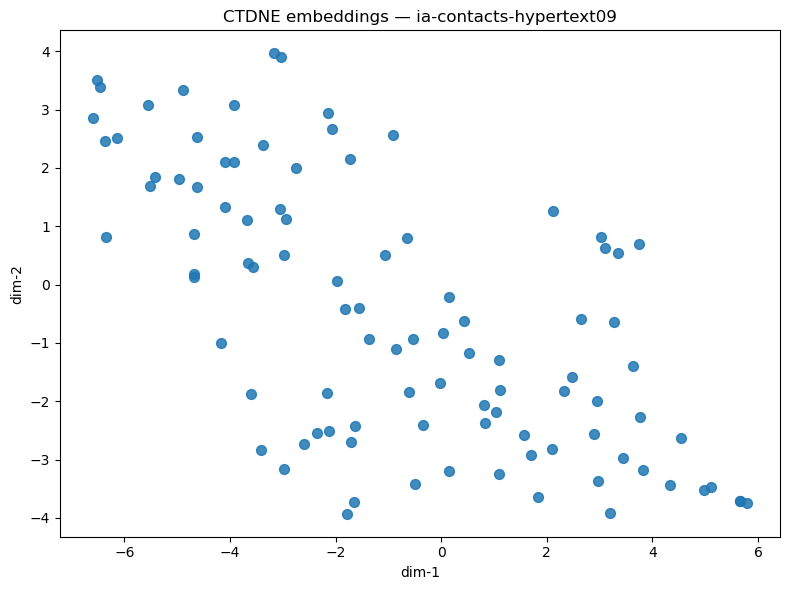

In [25]:
ids = [str(i) for i in range(num_nodes) if str(i) in model.wv]
X = np.array([model.wv[i] for i in ids])
xy = TSNE(n_components=2, random_state=0, perplexity=min(30, len(X)-1)).fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(xy[:, 0], xy[:, 1], s=50, alpha=0.85)
plt.title('CTDNE embeddings — ia-contacts-hypertext09')
plt.xlabel('dim-1'); plt.ylabel('dim-2')
plt.tight_layout()
plt.show()

# 4. DynGEM — Deep Embedding Method for Dynamic Graphs

**Idea:** At each time step, learn an **SDNE** graph autoencoder (first- and second-order proximity).  
**DynGEM** warm-starts the next snapshot from the previous model weights (incremental learning).

In [26]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from sklearn.manifold import TSNE

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data' / 'enron_small'
KONECT_FILE = ROOT / 'data' / 'enron_konect' / 'enron' / 'out.enron'

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)
print('PyTorch', torch.__version__)

PyTorch 2.11.0+cu130


## 4.1. Prepare Enron Snapshot 

In [27]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score


def load_konect_enron_edges(
    path: Path,
    max_edges: int | None = None,
) -> list[tuple[int, int, int]]:
    """Load KONECT out.enron: from to weight unix_ts."""
    edges: list[tuple[int, int, int]] = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.startswith("%") or not line.strip():
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            u, v, ts = int(parts[0]), int(parts[1]), int(parts[3])
            edges.append((u, v, ts))
            if max_edges and len(edges) >= max_edges:
                break
    return edges


def build_enron_snapshots(
    edges: list[tuple[int, int, int]],
    *,
    top_nodes: int = 150,
    n_snapshots: int = 10,
    undirected: bool = True,
) -> tuple[list[nx.Graph], dict[int, int]]:
    """Top-degree nodes on full stream; monthly cumulative snapshots."""
    deg: Counter[int] = Counter()
    for u, v, _ in edges:
        deg[u] += 1
        deg[v] += 1
    keep = {n for n, _ in deg.most_common(top_nodes)}
    filt = [(u, v, t) for u, v, t in edges if u in keep and v in keep]
    remap = {old: i for i, old in enumerate(sorted(keep))}

    filt.sort(key=lambda x: x[2])
    ts_vals = [t for _, _, t in filt]
    # Equal-time quantile cuts so each snapshot gains edges
    cuts = [ts_vals[int((i + 1) * len(ts_vals) / n_snapshots) - 1] for i in range(n_snapshots)]

    graphs: list[nx.Graph] = []
    n = len(keep)
    for cut in cuts:
        g = nx.Graph()
        g.add_nodes_from(range(n))
        for u, v, t in filt:
            if t <= cut:
                a, b = remap[u], remap[v]
                if a != b:
                    g.add_edge(a, b)
        graphs.append(g)
    return graphs, remap


def save_snapshots(graphs: list[nx.Graph], out_dir: Path) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    meta = {
        "n_snapshots": len(graphs),
        "nodes": graphs[-1].number_of_nodes(),
        "edges_per_snapshot": [g.number_of_edges() for g in graphs],
    }
    (out_dir / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
    for i, g in enumerate(graphs):
        n = g.number_of_nodes()
        adj = nx.to_numpy_array(g, nodelist=range(n), dtype=np.float32)
        np.savez_compressed(out_dir / f"snapshot_{i:02d}.npz", adj=adj, n_nodes=n)


def load_snapshots(data_dir: Path) -> list[nx.Graph]:
    files = sorted(data_dir.glob("snapshot_*.npz"))
    graphs: list[nx.Graph] = []
    for fp in files:
        z = np.load(fp)
        adj = z["adj"]
        n = int(z["n_nodes"])
        g = nx.from_numpy_array(adj)
        g = nx.relabel_nodes(g, {i: i for i in range(n)})
        graphs.append(g)
    return graphs


def graph_to_matrices(g: nx.Graph) -> tuple[np.ndarray, np.ndarray]:
    """Adjacency A and second-order proximity B (SDNE, DynamicGEM)."""
    n = g.number_of_nodes()
    A = nx.to_numpy_array(g, nodelist=range(n), dtype=np.float32)
    np.fill_diagonal(A, 0.0)
    deg = A.sum(axis=1, keepdims=True)
    deg[deg == 0] = 1.0
    An = A / deg
    B = An @ An.T
    np.fill_diagonal(B, 0.0)
    return A, B.astype(np.float32)

## 4.2. SDNE Autoencoder

In [28]:
class SDNEAutoencoder(nn.Module):
    def __init__(self, n_nodes: int, dim: int, hidden: tuple[int, ...] = (256, 128)):
        super().__init__()
        layers: list[nn.Module] = []
        in_d = n_nodes
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.Tanh()]
            in_d = h
        layers.append(nn.Linear(in_d, dim))
        self.encoder = nn.Sequential(*layers)
        dec_layers: list[nn.Module] = []
        in_d = dim
        for h in reversed(hidden):
            dec_layers += [nn.Linear(in_d, h), nn.Tanh()]
            in_d = h
        self.dec_a = nn.Sequential(*dec_layers, nn.Linear(in_d, n_nodes), nn.Sigmoid())
        self.dec_b = nn.Sequential(*dec_layers, nn.Linear(in_d, n_nodes), nn.Sigmoid())

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        z = self.encoder(x)
        return z, self.dec_a(z), self.dec_b(z)

## 4.3. SDNE Training on single snapshot

In [29]:
def _sdne_loss(
    a_hat: torch.Tensor,
    b_hat: torch.Tensor,
    a: torch.Tensor,
    b: torch.Tensor,
    model: SDNEAutoencoder,
    *,
    alpha: float = 1.0,
    beta: float = 5.0,
    nu1: float = 1e-6,
    nu2: float = 1e-6,
) -> torch.Tensor:
    la = alpha * torch.sum((a_hat - a) ** 2)
    lb = beta * torch.sum((b_hat - b) ** 2)
    reg = 0.0
    for p in model.parameters():
        reg = reg + nu1 * torch.sum(torch.abs(p)) + nu2 * torch.sum(p ** 2)
    return la + lb + reg


def train_sdne_snapshot(
    A: np.ndarray,
    B: np.ndarray,
    *,
    dim: int = 32,
    epochs: int = 80,
    lr: float = 1e-3,
    prev_model: SDNEAutoencoder | None = None,
    device: str | torch.device = "cpu",
    verbose: bool = False,
) -> tuple[np.ndarray, SDNEAutoencoder]:
    """Train SDNE on one snapshot; DynGEM warm-starts encoder/decoder weights."""
    n = A.shape[0]
    dev = torch.device(device)
    model = SDNEAutoencoder(n, dim).to(dev)
    if prev_model is not None and prev_model.encoder[0].in_features == n:
        model.load_state_dict(prev_model.state_dict())

    a_t = torch.tensor(A, device=dev)
    b_t = torch.tensor(B, device=dev)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for ep in range(epochs):
        opt.zero_grad()
        z, a_hat, b_hat = model(a_t)
        loss = _sdne_loss(a_hat, b_hat, a_t, b_t, model)
        loss.backward()
        opt.step()
        if verbose and (ep + 1) % 20 == 0:
            print(f"  epoch {ep+1}/{epochs} loss={float(loss):.2f}")
    model.eval()
    with torch.no_grad():
        z, _, _ = model(a_t)
    return z.cpu().numpy(), model

## 4.4. DynGEM Temporal Embedding Generation

In [30]:
def dyngem(
    graphs: list[nx.Graph],
    *,
    dim: int = 32,
    epochs: int = 80,
    lr: float = 1e-3,
    device: str = "cpu",
    verbose: bool = True,
) -> list[np.ndarray]:
    """DynGEM: SDNE per snapshot with embedding warm-start (Goyal et al., 2018)."""
    embs: list[np.ndarray] = []
    prev_model: SDNEAutoencoder | None = None
    for t, g in enumerate(graphs):
        A, B = graph_to_matrices(g)
        if verbose:
            print(f"t={t} nodes={g.number_of_nodes()} edges={g.number_of_edges()}")
        snap_epochs = epochs if t == 0 else max(epochs // 2, 20)
        y, prev_model = train_sdne_snapshot(
            A,
            B,
            dim=dim,
            epochs=snap_epochs,
            lr=lr,
            prev_model=prev_model,
            device=device,
            verbose=False,
        )
        embs.append(y)
    return embs

## 4.5. Link Prediction

In [31]:
def link_prediction_auc(
    graphs: list[nx.Graph],
    embeddings: list[np.ndarray],
) -> list[float]:
    """AUC for edges appearing in G_{t+1} \\ G_t (dot-product score)."""
    scores: list[float] = []
    for t in range(len(graphs) - 1):
        g_cur, g_next = graphs[t], graphs[t + 1]
        emb = embeddings[t]
        new_edges = set(map(tuple, g_next.edges)) - set(map(tuple, g_cur.edges))
        if not new_edges:
            continue
        nodes = list(g_cur.nodes())
        existing = set(map(tuple, g_cur.edges))
        rng = np.random.default_rng(t)

        def sc(a: int, b: int) -> float:
            return float(np.dot(emb[a], emb[b]))

        neg: list[tuple[int, int]] = []
        while len(neg) < min(len(new_edges), 200):
            u, v = int(rng.integers(0, len(nodes))), int(rng.integers(0, len(nodes)))
            if u == v:
                continue
            a, b = (min(u, v), max(u, v))
            if (a, b) not in existing:
                neg.append((a, b))
        y_true = [1] * len(new_edges) + [0] * len(neg)
        y_score = [sc(a, b) for a, b in new_edges] + [sc(a, b) for a, b in neg]
        if len(set(y_true)) < 2:
            continue
        scores.append(float(roc_auc_score(y_true, y_score)))
    return scores

## 4.6. Ensure ENRON small

In [32]:
def ensure_enron_small(
    konect_path: Path,
    out_dir: Path,
    *,
    top_nodes: int = 150,
    n_snapshots: int = 10,
    max_edges: int | None = None,
    force_rebuild: bool = False,
) -> list[nx.Graph]:
    if (out_dir / "meta.json").exists() and not force_rebuild:
        return load_snapshots(out_dir)
    edges = load_konect_enron_edges(konect_path, max_edges=max_edges)
    graphs, _ = build_enron_snapshots(
        edges, top_nodes=top_nodes, n_snapshots=n_snapshots
    )
    save_snapshots(graphs, out_dir)
    return graphs

## 4.7. Build small Enron snapshots

In [33]:
if not (DATA_DIR / 'meta.json').exists():
    assert KONECT_FILE.exists(), (
        'Download KONECT Enron first: see data/enron_konect/README'
    )
    edges = load_konect_enron_edges(KONECT_FILE)
    graphs, _ = build_enron_snapshots(edges, top_nodes=120, n_snapshots=8)
    save_snapshots(graphs, DATA_DIR)
else:
    graphs = load_snapshots(DATA_DIR)

meta = json.loads((DATA_DIR / 'meta.json').read_text())
print(meta)
for i, g in enumerate(graphs):
    print(f'  t={i}: nodes={g.number_of_nodes()} edges={g.number_of_edges()}')

{'n_snapshots': 8, 'nodes': 120, 'edges_per_snapshot': [562, 753, 873, 965, 1110, 1264, 1353, 1508]}
  t=0: nodes=120 edges=562
  t=1: nodes=120 edges=753
  t=2: nodes=120 edges=873
  t=3: nodes=120 edges=965
  t=4: nodes=120 edges=1110
  t=5: nodes=120 edges=1264
  t=6: nodes=120 edges=1353
  t=7: nodes=120 edges=1508


## 4.8. SDNE matrices (first- and second-order proximity)

For adjacency **A**, normalized neighbors give second-order matrix **B**.

In [34]:
A, B = graph_to_matrices(graphs[-1])
print('A shape', A.shape, 'density', A.sum() / (A.shape[0] ** 2))
print('B shape', B.shape, 'nonzeros', int((B > 0).sum()))

A shape (120, 120) density 0.20944445
B shape (120, 120) nonzeros 11988


## 4.9. Train across snapshots

In [35]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EMBED_DIM = 32
EPOCHS = 60

embeddings = dyngem(
    graphs,
    dim=EMBED_DIM,
    epochs=EPOCHS,
    device=DEVICE,
    verbose=True,
)
print(f'Embedding dim: {embeddings[-1].shape[1]}')

t=0 nodes=120 edges=562
t=1 nodes=120 edges=753
t=2 nodes=120 edges=873
t=3 nodes=120 edges=965
t=4 nodes=120 edges=1110
t=5 nodes=120 edges=1264
t=6 nodes=120 edges=1353
t=7 nodes=120 edges=1508
Embedding dim: 32


## 4.10. Evaluate by link prediction

In [36]:
aucs = link_prediction_auc(graphs, embeddings)
for i, a in enumerate(aucs):
    print(f'  step {i} -> {i+1}: AUC = {a:.3f}')
if aucs:
    print(f'Mean AUC: {np.mean(aucs):.3f}')

  step 0 -> 1: AUC = 0.662
  step 1 -> 2: AUC = 0.606
  step 2 -> 3: AUC = 0.689
  step 3 -> 4: AUC = 0.611
  step 4 -> 5: AUC = 0.580
  step 5 -> 6: AUC = 0.678
  step 6 -> 7: AUC = 0.710
Mean AUC: 0.648


## 4.11. Visualize final snapshot embeddings

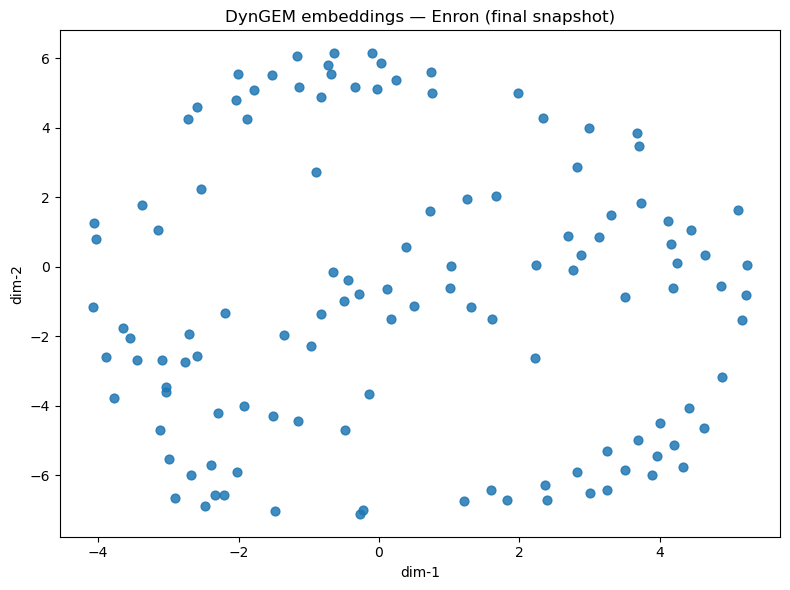

In [37]:
Y = embeddings[-1]
xy = TSNE(n_components=2, random_state=0, perplexity=min(30, len(Y) - 1)).fit_transform(Y)

plt.figure(figsize=(8, 6))
plt.scatter(xy[:, 0], xy[:, 1], s=40, alpha=0.85)
plt.title('DynGEM embeddings — Enron (final snapshot)')
plt.xlabel('dim-1'); plt.ylabel('dim-2')
plt.tight_layout()
plt.show()

# 5. Dynamic Network Embedding by Modeling Triadic Closure Process (DynamicTriad)

Use **time-aware embeddings** $u_i^{(t)}$ for node $i$ at time step $t$.

DynamicTriad's core innovation is modeling the **triadic closure process** — a fundamental mechanism of network evolution:

- An **open triad** is a triple of nodes $(i,j,k)$ where $i$ is connected to both $j$ and $k$, but $j$ and $k$ are *not* yet connected.
- **Triadic closure** occurs when the missing edge $j$-$k$ appears in a later snapshot ( "friend of a friend becomes a friend").

The model learns embeddings such that:
1. **Structural proximity** is preserved at each time step (connected nodes have similar embeddings).
2. **Temporal smoothness**: embeddings of the same node change gradually ($\mathbf{u}_i^{(t)} \approx \mathbf{u}_i^{(t-1)}$).
3. **Triad closure likelihood**: the probability that an open triad closes can be predicted from the embeddings of the three nodes at the previous time step. The training objective directly optimizes for this predictive power.


## 5.1. Setup

In [38]:
import numpy as np
import networkx as nx
import random
import json
from collections import defaultdict

import torch
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

## 5.2. Create fake ACADEMIC dataset

In [39]:
FIELDS = ['ML', 'Theory', 'Systems', 'Databases']
FIELD_COLORS = {'ML': '#1f77b4', 'Theory': '#ff7f0e', 'Systems': '#2ca02c', 'Databases': '#d62728'}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def generate_academic_dynamic_graph(
    n_authors=64, n_steps=8, years_start=2010,
    p_intra=0.12, p_inter=0.002, triad_close_prob=0.42,
    edge_persist=0.82, new_edge_per_node=0.8, seed=42
):
    """Synthetic co-authorship network with triadic closure dynamics."""
    set_seed(seed)
    n_fields = len(FIELDS)
    n_per = n_authors // n_fields
    node_fields = []
    for f in FIELDS:
        node_fields.extend([f] * n_per)
    while len(node_fields) < n_authors:
        node_fields.append(FIELDS[-1])
    node_fields = node_fields[:n_authors]

    field_to_nodes = defaultdict(list)
    for i, f in enumerate(node_fields):
        field_to_nodes[f].append(i)

    graphs = []
    prev = nx.Graph()
    prev.add_nodes_from(range(n_authors))

    for t in range(n_steps):
        G = nx.Graph()
        G.add_nodes_from(range(n_authors))

        # persist
        if t > 0:
            for u, v in prev.edges():
                if random.random() < edge_persist:
                    G.add_edge(u, v)

        # base intra-field
        for f in FIELDS:
            nodes_f = field_to_nodes[f]
            for i in range(len(nodes_f)):
                u = nodes_f[i]
                for j in range(i+1, len(nodes_f)):
                    v = nodes_f[j]
                    if not G.has_edge(u, v) and random.random() < p_intra:
                        G.add_edge(u, v)

        # rare inter
        for fi in range(n_fields):
            for fj in range(fi+1, n_fields):
                ni = field_to_nodes[FIELDS[fi]]
                nj = field_to_nodes[FIELDS[fj]]
                for u in ni:
                    for v in nj:
                        if not G.has_edge(u, v) and random.random() < p_inter:
                            G.add_edge(u, v)

        # triadic closure bias
        adj = {u: set(G.neighbors(u)) for u in range(n_authors)}
        candidates = set()
        for u in range(n_authors):
            nbrs = list(adj[u])
            for ii in range(len(nbrs)):
                a = nbrs[ii]
                for jj in range(ii+1, len(nbrs)):
                    b = nbrs[jj]
                    aa, bb = min(a, b), max(a, b)
                    if not G.has_edge(aa, bb):
                        candidates.add((aa, bb))
        for a, b in list(candidates):
            if random.random() < triad_close_prob:
                G.add_edge(a, b)

        # exploration
        for _ in range(int(n_authors * new_edge_per_node)):
            u = random.randrange(n_authors)
            v = random.randrange(n_authors)
            if u != v and not G.has_edge(u, v):
                p = 0.025 if (node_fields[u] == node_fields[v]) else 0.0015
                if random.random() < p:
                    G.add_edge(u, v)

        graphs.append(nx.Graph(G))
        prev = G

    years = list(range(years_start, years_start + n_steps))
    return graphs, node_fields, years

graphs, node_fields, years = generate_academic_dynamic_graph()
print(f"Generated {len(graphs)} snapshots, {graphs[0].number_of_nodes()} nodes.")
for t, G in enumerate(graphs):
    print(f"  Year {years[t]}: {G.number_of_edges()} edges")
    
# Homophily
total_edges = sum(G.number_of_edges() for G in graphs)
same = sum(1 for G in graphs for u,v in G.edges() if node_fields[u] == node_fields[v])
print(f"Overall same-field edge ratio: {same/total_edges:.3f}")

Generated 8 snapshots, 64 nodes.
  Year 2010: 90 edges
  Year 2011: 234 edges
  Year 2012: 372 edges
  Year 2013: 627 edges
  Year 2014: 1048 edges
  Year 2015: 1338 edges
  Year 2016: 1517 edges
  Year 2017: 1601 edges
Overall same-field edge ratio: 0.382


In [40]:
import os
def save_adjlist_format(graphs, outdir="new_academic_small_adjlist"):
    os.makedirs(outdir, exist_ok=True)
    for t, G in enumerate(graphs):
        with open(os.path.join(outdir, str(t)), "w") as f:
            for u in sorted(G.nodes()):
                nbrs = sorted(G.neighbors(u))
                parts = []
                for v in nbrs:
                    parts.extend([str(v), "1.0"])
                f.write(f"{u} " + " ".join(parts) + "\n" if parts else f"{u}\n")
    print("Saved adjlist snapshots to", outdir)
    
save_adjlist_format(graphs)

Saved adjlist snapshots to new_academic_small_adjlist


## 5.3. DynamicTriad

**Loss terms:**
- `struct_loss`: At each $t$, connected nodes should be close in embedding space (use squared Euclidean distance + logistic loss with negative sampling).
- `smooth_loss`: $\|E^{(t)} - E^{(t-1)}\|_F^2$ (embeddings of a node evolve smoothly).
- `triad_loss`: For open triads at time $t$, predict whether the missing edge will appear at $t+1$ using a simple dot-product scorer on the embeddings at time $t$. Binary cross-entropy against the observed closure label.

The embeddings $E \in \mathbb{R}^{T \times N \times D}$ are optimized jointly.

In [41]:
def sample_structural(pos_edges, n_nodes, neg_ratio=1, max_samples=600):
    pos_u, pos_v = [], []
    for u, v in pos_edges:
        if u < v:
            pos_u.append(u); pos_v.append(v)
    if len(pos_u) > max_samples:
        idx = np.random.choice(len(pos_u), max_samples, replace=False)
        pos_u = [pos_u[i] for i in idx]
        pos_v = [pos_v[i] for i in idx]
    n_pos = len(pos_u)
    n_neg = max(50, int(n_pos * neg_ratio))
    neg_u, neg_v = [], []
    pos_set = set(zip(pos_u, pos_v))
    attempts = 0
    while len(neg_u) < n_neg and attempts < n_neg*25 + 2000:
        attempts += 1
        u = random.randrange(n_nodes); v = random.randrange(n_nodes)
        if u < v and (u, v) not in pos_set:
            neg_u.append(u); neg_v.append(v); pos_set.add((u,v))
    return (torch.tensor(pos_u, dtype=torch.long),
            torch.tensor(pos_v, dtype=torch.long),
            torch.tensor(neg_u, dtype=torch.long),
            torch.tensor(neg_v, dtype=torch.long))

def build_triad_candidates(graphs, max_per_step=280):
    """Sample open triads and whether they closed in the next snapshot."""
    T = len(graphs)
    triad_events = []
    for t in range(T-1):
        G, Gnext = graphs[t], graphs[t+1]
        adj = {u: set(G.neighbors(u)) for u in G.nodes()}
        events, seen = [], set()
        nodes = list(G.nodes()); random.shuffle(nodes)
        for i in nodes:
            nbrs = list(adj[i])
            if len(nbrs) < 2: continue
            random.shuffle(nbrs)
            for ii in range(min(8, len(nbrs))):
                a = nbrs[ii]
                for jj in range(ii+1, min(ii+6, len(nbrs))):
                    b = nbrs[jj]
                    aa, bb = min(a,b), max(a,b)
                    if (aa,bb) in seen or G.has_edge(aa, bb): continue
                    seen.add((aa,bb))
                    label = 1 if Gnext.has_edge(aa, bb) else 0
                    events.append((aa, bb, label))
                    if len(events) > max_per_step * 2: break
                if len(events) > max_per_step * 2: break
            if len(events) > max_per_step * 2: break
        if len(events) > max_per_step:
            pos = [e for e in events if e[2] == 1]
            neg = [e for e in events if e[2] == 0]
            random.shuffle(pos); random.shuffle(neg)
            k = min(len(pos), max_per_step // 2 + 20)
            events = pos[:k] + neg[:max(0, max_per_step - k)]
        triad_events.append(events)
    return triad_events

def struct_loss(emb, pu, pv, nu, nv):
    """Logistic loss on squared Euclidean distances."""
    dpos = torch.sum((emb[pu] - emb[pv]) ** 2, dim=1)
    loss_pos = F.softplus( dpos ).mean()          # encourage small dist for pos (score = -dist2)
    # wait, sign fix: we had score = -dist2, loss for pos = softplus(-score) = softplus(dist2)
    # for neg: softplus( - (-dist2) wait let's redo cleanly
    # Better:
    # score = -dist2 ; loss_pos = softplus(-score) = softplus(dist2)  [yes for label=1]
    dneg = torch.sum((emb[nu] - emb[nv]) ** 2, dim=1)
    loss_neg = F.softplus( -dneg ).mean()         # encourage large dist for neg -> score_neg low
    return (loss_pos + loss_neg) / 2

def smooth_loss(E):
    if E.shape[0] <= 1: return torch.tensor(0., device=E.device)
    return torch.mean((E[1:] - E[:-1]) ** 2)

def triad_loss(E, events, t):
    if t >= len(events) or len(events[t]) == 0:
        return torch.tensor(0., device=E.device)
    js = torch.tensor([e[0] for e in events[t]], dtype=torch.long, device=E.device)
    ks = torch.tensor([e[1] for e in events[t]], dtype=torch.long, device=E.device)
    y  = torch.tensor([e[2] for e in events[t]], dtype=torch.float32, device=E.device)
    scores = torch.sum(E[t, js] * E[t, ks], dim=1)
    return F.binary_cross_entropy_with_logits(scores, y)

## 5.4. Train

In [42]:
def train_dynamic_triad(graphs, emb_dim=16, niters=40, lr=0.16,
                        beta_smooth=0.4, beta_triad=1.0, negdup=1,
                        device=None, seed=42, verbose=True):
    set_seed(seed)
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    N, T = graphs[0].number_of_nodes(), len(graphs)
    print(f"DynamicTriad training: N={N}, T={T}, D={emb_dim} on {device}")

    edge_lists = [list(G.edges()) for G in graphs]
    triad_events = build_triad_candidates(graphs, max_per_step=280)
    print(f"  Triad supervision samples: {sum(len(e) for e in triad_events)}")

    E = torch.nn.Parameter(torch.randn(T, N, emb_dim, device=device) * 0.04)
    opt = Adam([E], lr=lr)

    history = []
    for it in range(niters):
        opt.zero_grad()
        loss_s = torch.tensor(0., device=device)
        for t in range(T):
            if not edge_lists[t]: continue
            pu, pv, nu, nv = sample_structural(edge_lists[t], N, neg_ratio=negdup)
            pu, pv, nu, nv = pu.to(device), pv.to(device), nu.to(device), nv.to(device)
            loss_s = loss_s + struct_loss(E[t], pu, pv, nu, nv)
        loss_s = loss_s / T

        loss_sm = smooth_loss(E)
        loss_tr = sum(triad_loss(E, triad_events, t) for t in range(T-1)) / max(T-1, 1)

        total = loss_s + beta_smooth * loss_sm + beta_triad * loss_tr
        total.backward()
        opt.step()

        history.append(dict(total=float(total), struct=float(loss_s),
                            smooth=float(loss_sm), triad=float(loss_tr)))
        if verbose and (it % 8 == 0 or it == niters-1):
            h = history[-1]
            print(f"[{it:2d}] total={h['total']:.4f} | struct={h['struct']:.4f} "
                  f"smooth={h['smooth']:.4f} triad={h['triad']:.4f}")
    return E.detach().cpu().numpy(), history, triad_events

In [43]:
E_dyn, loss_hist, _ = train_dynamic_triad(
    graphs, emb_dim=16, niters=40, lr=0.16,
    beta_smooth=0.4, beta_triad=1.0, negdup=1, seed=42, verbose=True
)
print("Trained dynamic embeddings shape:", E_dyn.shape)

DynamicTriad training: N=64, T=8, D=16 on cuda
  Triad supervision samples: 1760


/tmp/ipykernel_125908/3377959507.py:35: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  history.append(dict(total=float(total), struct=float(loss_s),


[ 0] total=1.3882 | struct=0.6938 smooth=0.0031 triad=0.6932
[ 8] total=1.2973 | struct=0.6466 smooth=0.0703 triad=0.6226
[16] total=1.2609 | struct=0.6372 smooth=0.0500 triad=0.6037
[24] total=1.2504 | struct=0.6337 smooth=0.0365 triad=0.6021
[32] total=1.2443 | struct=0.6306 smooth=0.0326 triad=0.6007
[39] total=1.2395 | struct=0.6276 smooth=0.0296 triad=0.6001
Trained dynamic embeddings shape: (8, 64, 16)


## 5.5. Compare with baseline

In [44]:
def train_static_per_snapshot(graphs, emb_dim=16, niters=30, lr=0.2, negdup=1, device=None, seed=42):
    set_seed(seed)
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    N = graphs[0].number_of_nodes()
    edge_lists = [list(G.edges()) for G in graphs]
    T = len(graphs)
    all_E = []
    for t in range(T):
        E_t = torch.nn.Parameter(torch.randn(N, emb_dim, device=device) * 0.05)
        opt = Adam([E_t], lr=lr)
        for it in range(niters):
            opt.zero_grad()
            if not edge_lists[t]:
                all_E.append(E_t.detach().cpu().numpy()); break
            pu, pv, nu, nv = sample_structural(edge_lists[t], N, neg_ratio=negdup)
            pu, pv, nu, nv = [x.to(device) for x in (pu, pv, nu, nv)]
            ls = struct_loss(E_t, pu, pv, nu, nv)
            ls.backward()
            opt.step()
        all_E.append(E_t.detach().cpu().numpy())
    return np.stack(all_E, axis=0)  # (T, N, D)

E_static = train_static_per_snapshot(graphs, emb_dim=16, niters=30, seed=42)
print("Static embeddings shape:", E_static.shape)

Static embeddings shape: (8, 64, 16)


## 5.6. Evaluate

In [45]:
def evaluate_link_reconstruction(embs_t, G, n_samples=800):
    """AUC for link reconstruction on a snapshot using embedding distances."""
    pos = [(u,v) for u,v in G.edges() if u < v]
    if len(pos) > n_samples: 
        pos = random.sample(pos, n_samples)
    neg = []
    pos_set = set(pos)
    while len(neg) < len(pos):
        u = random.randrange(len(embs_t)); v = random.randrange(len(embs_t))
        if u < v and (u,v) not in pos_set:
            neg.append((u,v))
    def sc(a,b):
        return -np.sum((embs_t[a] - embs_t[b])**2)
    y = [1]*len(pos) + [0]*len(neg)
    s = [sc(u,v) for u,v in pos] + [sc(u,v) for u,v in neg]
    return roc_auc_score(y, s)

print("Link reconstruction AUC (last snapshot):")
print(f"  DynamicTriad: {evaluate_link_reconstruction(E_dyn[-1], graphs[-1]):.3f}")
print(f"  Static indep: {evaluate_link_reconstruction(E_static[-1], graphs[-1]):.3f}")

Link reconstruction AUC (last snapshot):
  DynamicTriad: 0.519
  Static indep: 0.493


In [46]:
def evaluate_field_prediction(embs_t, node_fields, cv=5):
    X = embs_t
    y = LabelEncoder().fit_transform(node_fields)
    clf = LogisticRegression(max_iter=2000, solver="lbfgs")
    try:
        f1s = cross_val_score(clf, X, y, cv=cv, scoring="f1_macro")
        return float(np.mean(f1s))
    except Exception as e:
        return float("nan")

print("Field classification F1-macro (last snapshot, 5-fold):")
print(f"  DynamicTriad: {evaluate_field_prediction(E_dyn[-1], node_fields):.3f}")
print(f"  Static indep: {evaluate_field_prediction(E_static[-1], node_fields):.3f}")

Field classification F1-macro (last snapshot, 5-fold):
  DynamicTriad: 0.228
  Static indep: 0.212


## 5.7. Visualize

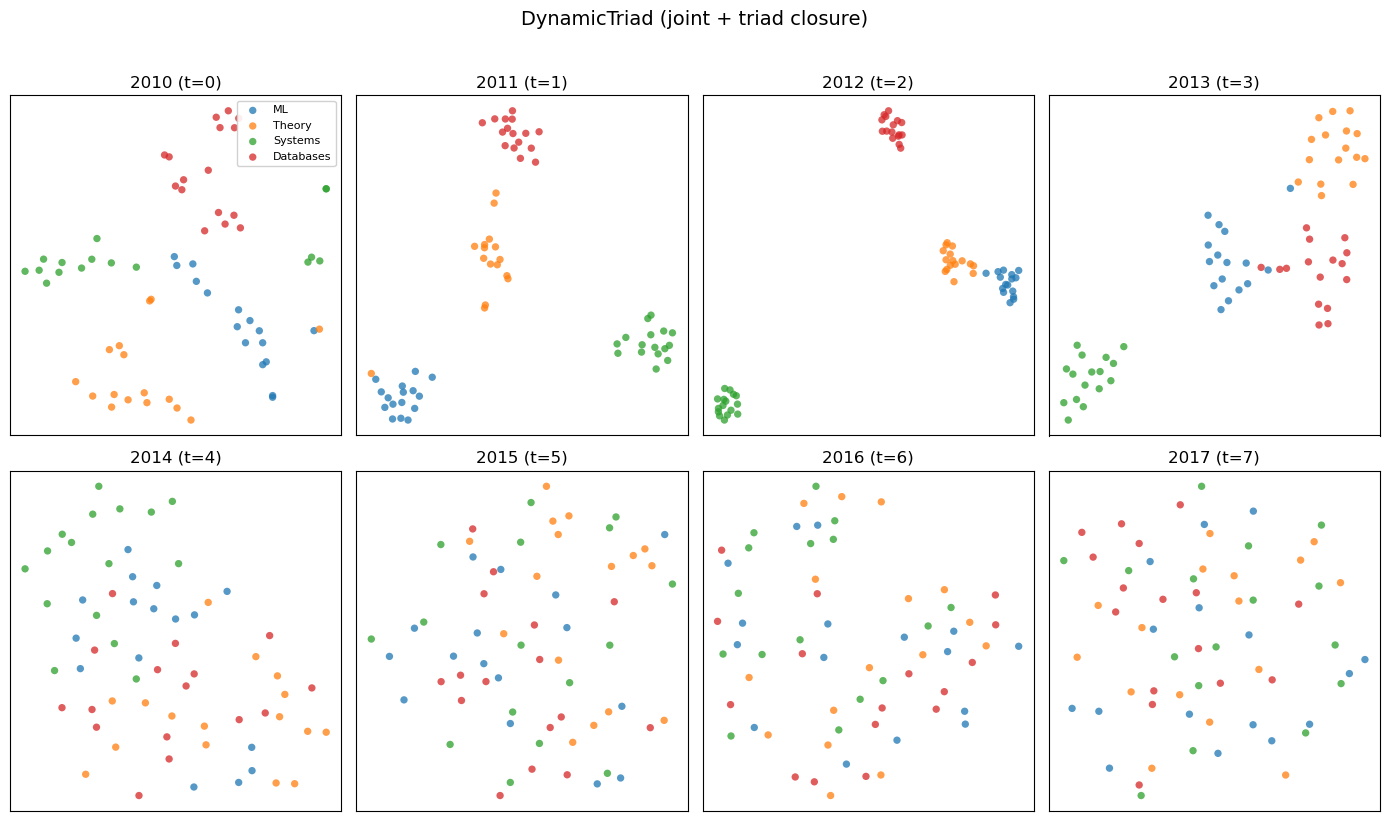

In [47]:
def plot_embedding_evolution(E, node_fields, years, title="DynamicTriad Embeddings over Time", figsize=(14, 8)):
    T = E.shape[0]
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.flatten()
    for t in range(T):
        ax = axes[t]
        emb2d = TSNE(n_components=2, perplexity=12, random_state=42, init="random", learning_rate="auto").fit_transform(E[t])
        for f in FIELDS:
            mask = np.array(node_fields) == f
            ax.scatter(emb2d[mask, 0], emb2d[mask, 1], c=FIELD_COLORS[f], label=f, s=28, alpha=0.75, edgecolors="none")
        ax.set_title(f"{years[t]} (t={t})")
        ax.set_xticks([]); ax.set_yticks([])
        if t == 0:
            ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
plot_embedding_evolution(E_dyn, node_fields, years, "DynamicTriad (joint + triad closure)")

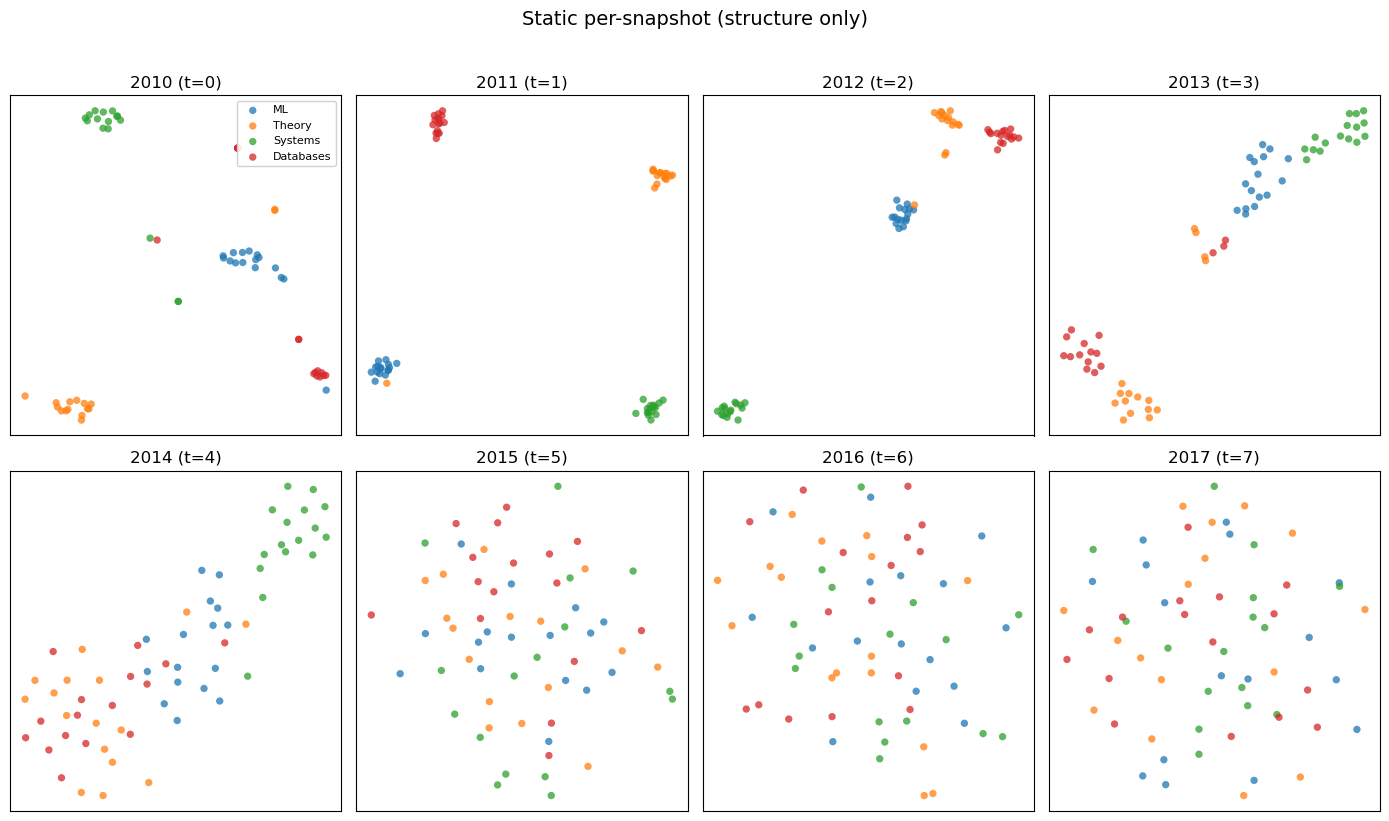

In [48]:
plot_embedding_evolution(E_static, node_fields, years, "Static per-snapshot (structure only)")